In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

c:\ProgramData\anaconda3\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preview the data

Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


                                                 text  label
0   Wall St. Bears Claw Back Into the Black (Reute...      2
1   Carlyle Looks Toward Commercial Aerospace (Reu...      2
2   Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3   Iraq Halts Oil Exports from Main Southern Pipe...      2
4   Oil prices soar to all-time record, posing new...      2
..                                                ...    ...
95  Gene Blocker Turns Monkeys Into Workaholics - ...      3
96  Dolphins Too Have Born Socialites (Reuters) Re...      3
97  What's in a Name? Well, Matt Is Sexier Than Pa...      3
98  UK Scientists Allowed to Clone Human Embryos (...      3
99  Russian Alien Spaceship Claims Raise Eyebrows,...      3

[100 rows x 2 columns]


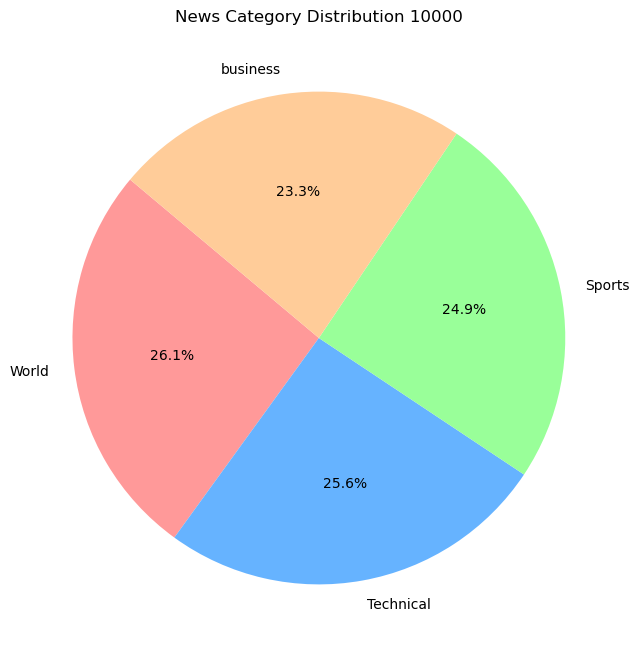

In [2]:
# Create a function for previewing the dataset
stream_for_preview = load_dataset("ag_news", split="train", streaming=True)
predataset = []
for pre in stream_for_preview.take(20000):
    predataset.append({
        'text': pre['text'],
        'label': pre['label']
    })
dataFrame_predataset = pd.DataFrame(predataset)
print(dataFrame_predataset.head(100))


# visualize the category distribution
# make sure the data is balanced
label_map = {0: "World", 1: "Sports", 2:"business", 3:"Technical"}
dataFrame_predataset['label_name'] = dataFrame_predataset['label'].map(label_map)
category_counts = dataFrame_predataset['label_name'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
plt.title(f'News Category Distribution 10000')
plt.show()


### Normalizer for the length of text

In [3]:
# make length to be a num around 0
# formula: (x - mean) / variance
normalize_layer = tf.keras.layers.Normalization(axis=None)
stream_for_normalizer = load_dataset("ag_news", split="train", streaming=True)
sample_lengths = []
for i in stream_for_normalizer.take(20000):
    length = len(i['text'].split())
    sample_lengths.append(length)
normalize_layer.adapt(np.array(sample_lengths))

print(normalize_layer.mean)
print(normalize_layer.variance)

Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


tf.Tensor([38.47497], shape=(1,), dtype=float32)
tf.Tensor([128.89105], shape=(1,), dtype=float32)


### Check the distribution of different length of data

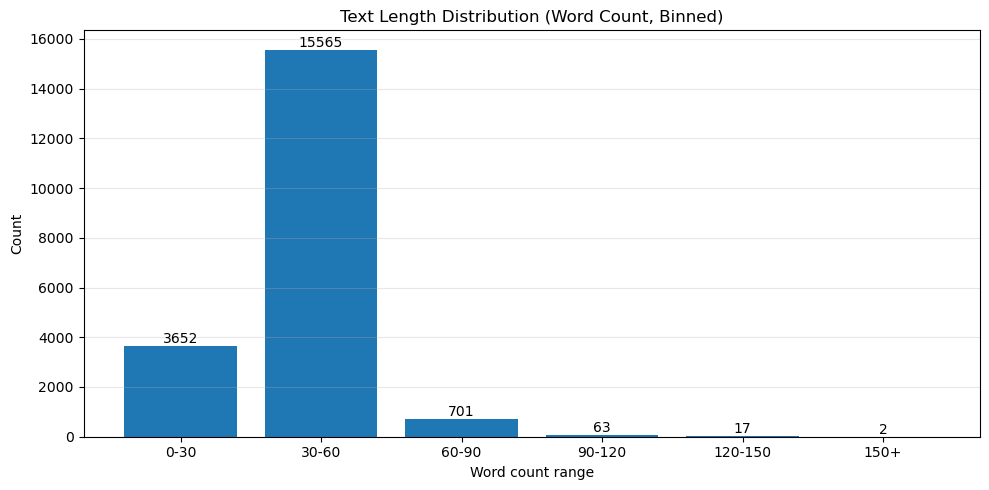

In [4]:
# separate the data to：0-100, 100-200, 200-300, 300-400, 400-500, 500+
bins = [0, 30, 60, 90, 120, 150, np.inf]
labels = ["0-30", "30-60", "60-90", "90-120", "120-150", "150+"]

counts, _ = np.histogram(sample_lengths, bins=bins)

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, counts)

plt.title("Text Length Distribution (Word Count, Binned)")
plt.xlabel("Word count range")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha='center', va='bottom', fontsize=10
    )
plt.show()


#### Vectorize

In [5]:
MAX_VOCABULARY_SIZE = 20000
SEQUENCE_LENGTH = 300
vectorize_layer = layers.TextVectorization(
    max_tokens = MAX_VOCABULARY_SIZE,
    output_sequence_length = SEQUENCE_LENGTH,
    output_mode = "int",
)

stream_for_vectorize = load_dataset("ag_news", split="train", streaming=True)
text_list = []
for i in stream_for_vectorize.take(20000):
    text_list.append(i['text'])
vectorize_layer.adapt(text_list)

test_vectorize = "Nvidia releases new AI chip."
print(vectorize_layer([test_vectorize]).numpy())

Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


[[6381 1976   16 6974  511    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0   

### Build the tube of data

In [6]:
def data_generator(split_name):
    hf_stream = load_dataset("ag_news", split=split_name, streaming=True)

    for i in hf_stream:
        text = i['text']
        label = i['label']
        length = float(len(text.split()))
        yield ((text, length), label)

# TF need strong typed data, but python is a weak typed langrage
# So we need to define the type of data for TF
output_signature = (
    (
    tf.TensorSpec(shape=(), dtype=tf.string),
    tf.TensorSpec(shape=(), dtype=tf.float32),
    ),
    tf.TensorSpec(shape=(), dtype=tf.int32)
)


# 1. 先构建完整的训练集流
agnews_train_ds = tf.data.Dataset.from_generator(
    lambda: data_generator("train"),
    output_signature=output_signature
).enumerate()


def is_val_data(index, data):
    return index % 10 == 0
def is_train_data(index, data):
    return not is_val_data(index, data)
def remove_index(index, data):
    return data

BATCH_SIZE = 128

train_ds = val_ds = agnews_train_ds.filter(is_train_data)\
                        .map(remove_index)\
                        .shuffle(buffer_size=10000)\
                        .batch(BATCH_SIZE)\
                        .prefetch(tf.data.AUTOTUNE)

val_ds = agnews_train_ds.filter(is_val_data)\
                        .map(remove_index)\
                        .batch(BATCH_SIZE)\
                        .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: data_generator("test"),
    output_signature=output_signature
)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("sepaerate data successful:")
print(f"Validation: for Early Stopping and adjusting hyperparameters")
print(f"Train: for model training")
print(f"Test: for the final evaluation")

# small example
print("\n--- preview (Taking 1 Batch) ---")

for inputs, targets in train_ds.take(1):
    # inputs is a tuple: (text_batch, length_batch)
    text_batch, length_batch = inputs
    label_batch = targets
    
    # check the shapes
    print(f"Text Batch Shape:   {text_batch.shape}")
    print(f"Length Batch Shape: {length_batch.shape}")
    print(f"Label Batch Shape:  {label_batch.shape}")
    
    # print the first data sample
    print("\n--- first data sample ---")
    print(f"Text:   {text_batch[0].numpy().decode('utf-8')[:100]}...")
    print(f"Length: {length_batch[0].numpy()}")
    print(f"Label:  {label_batch[0].numpy()}")


sepaerate data successful:
Validation: for Early Stopping and adjusting hyperparameters
Train: for model training
Test: for the final evaluation

--- preview (Taking 1 Batch) ---


Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


Text Batch Shape:   (128,)
Length Batch Shape: (128,)
Label Batch Shape:  (128,)

--- first data sample ---
Text:   Olympic Soccer: Euphoric Iraq Reaches Semifinals Iraq #39;s footballers beat Australia 1-0 Saturday ...
Length: 30.0
Label:  1


### Build the model

In [7]:
EMBEDDING_DIM = 128
NUM_CLASSES = 4

def build_model(input_normalize_layer, input_vectorlize_layer, dropout_rate=0.5):
    text_input = keras.Input(shape=(), dtype=tf.string, name="text_input")
    x = input_vectorlize_layer(text_input)
    x = layers.Embedding(MAX_VOCABULARY_SIZE, EMBEDDING_DIM)(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    len_input = keras.Input(shape=(1,), dtype=tf.float32, name="length_input")
    y = input_normalize_layer(len_input)
    y = layers.Dense(16, activation="relu")(y)
    y = layers.Dense(8, activation="relu")(y)

    combined = layers.concatenate([x,y])

    z = layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(combined)
    z = layers.Dropout(dropout_rate)(z)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(z)

    return keras.Model(inputs=[text_input,len_input], outputs=output)
    
    

### Train

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [1e-3, 1e-4]
dropout_rates = [0.3, 0.5]

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.001,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

best = {"val_acc": -1.0, "lr": None, "dropout": None, "model": None, "history": None}

trial = 0
for lr in learning_rates:
    for dr in dropout_rates:
        trial += 1
        print(f"\n=== Trial {trial}: lr={lr}, dropout={dr} ===")

        tf.keras.backend.clear_session()

        model = build_model(normalize_layer, vectorize_layer, dropout_rate=dr)
        model.compile(
            loss="sparse_categorical_crossentropy",
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            metrics=["accuracy"],
        )

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=20,
            callbacks=[early_stopping],
            verbose=1
        )

        best_val_acc = max(history.history["val_accuracy"])
        print(f"Best val_accuracy: {best_val_acc:.4f}")

        if best_val_acc > best["val_acc"]:
            best.update({"val_acc": best_val_acc, "lr": lr, "dropout": dr, "model": model, "history": history.history})

print("\n🏆 Best hyperparameters:")
print(f"lr={best['lr']}, dropout={best['dropout']}, best_val_acc={best['val_acc']:.4f}")



=== Trial 1: lr=0.001, dropout=0.3 ===
Epoch 1/20


Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


    844/Unknown - 96s 59ms/step - loss: 0.4720 - accuracy: 0.8213

Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


844/844 [==============================] - 181s 160ms/step - loss: 0.4720 - accuracy: 0.8213 - val_loss: 0.2873 - val_accuracy: 0.9070
Epoch 2/20


...

844/844 [==============================] - 167s 156ms/step - loss: 0.2327 - accuracy: 0.9376 - val_loss: 0.3077 - val_accuracy: 0.9126
Epoch 7/20


Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


841/844 [============================>.] - ETA: 0s - loss: 0.2035 - accuracy: 0.9459

Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


Restoring model weights from the end of the best epoch: 4.
844/844 [==============================] - 165s 154ms/step - loss: 0.2034 - accuracy: 0.9459 - val_loss: 0.3217 - val_accuracy: 0.9121
Epoch 7: early stopping
Best val_accuracy: 0.9139

🏆 Best hyperparameters:
lr=0.0001, dropout=0.5, best_val_acc=0.9139


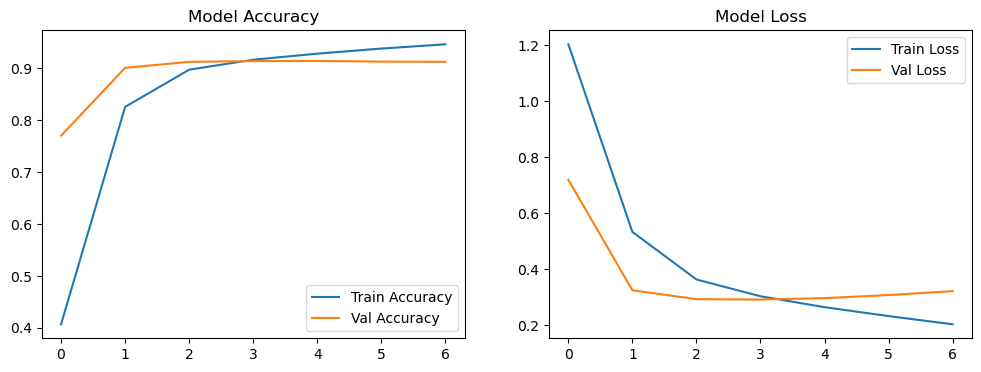

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

### Test model and Visualize the result

In [10]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
y_true = []
y_pred = []

# test the model
for inputs, labels in test_ds:
    predictions = model.predict(inputs, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

class_names = ["World", "Sports", "Business", "Sci/Tech"]

print(classification_report(y_true, y_pred, target_names=class_names))



Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


60/60 [==============================] - 34s 47ms/step - loss: 0.3208 - accuracy: 0.9075


Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Levi\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Nov 22 05:13:38 2025).


              precision    recall  f1-score   support

       World       0.92      0.91      0.92      1900
      Sports       0.95      0.97      0.96      1900
    Business       0.86      0.89      0.87      1900
    Sci/Tech       0.90      0.86      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



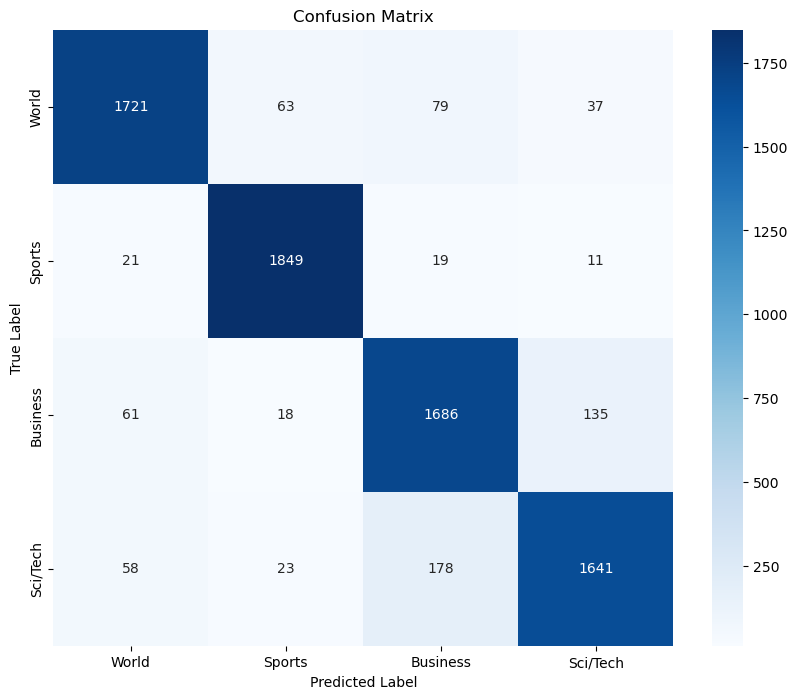

In [11]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()